# **Project Overview & Problem Statement**

* **The Core Problem:** Grid operators and households need accurate future energy forecasting to optimize distribution and reduce costs. However, time-series data is highly volatile, filled with missing data, and deeply influenced by human behavior and seasonal patterns.

* **The Project's Actual Scope:**  Before we can safely forecast the future, we must determine which modeling methodology handles this volatility best. Therefore, this project focuses on a comparative evaluation between classical statistical models (SARIMA) and modern automated forecasting frameworks (Meta Prophet) to identify the most robust predictive engine for household electricity consumption.**




#  **Dataset Documentation & Metadata**

##  Dataset Overview
* **Source:** Individual Household Electric Power Consumption Dataset
* **Temporal Horizon:** December 2006 – November 2010 (47 Months)
* **Total Volume:** 2,075,259 measurements (minute-by-minute granularity)
* **Data Integrity Note:** Approximately **1.25%** of rows contain missing values (represented as null spaces between separators). These require chronological time-based imputation.

---

##  Feature Architecture & Metadata

| Attribute Name | Data Type | Measurement Unit | Context / Description |
| :--- | :--- | :--- | :--- |
| **`Date`** | Object / Temporal | `dd/mm/yyyy` | Calendar date of recording. |
| **`Time`** | Object / Temporal | `hh:mm:ss` | Timestamps of minute-averaged logs. |
| **`Global_active_power`** | Numeric | Kilowatt (kW) | Household global minute-averaged active power. |
| **`Global_reactive_power`**| Numeric | Kilowatt (kW) | Household global minute-averaged reactive power. |
| **`Voltage`** | Numeric | Volt (V) | Minute-averaged voltage values. |
| **`Global_intensity`** | Numeric | Ampere (A) | Minute-averaged current intensity. |
| **`Sub_metering_1`** | Numeric | Watt-hour (Wh) | **Zone 1 (Kitchen):** Dishwasher, oven, microwave (excluding gas appliances). |
| **`Sub_metering_2`** | Numeric | Watt-hour (Wh) | **Zone 2 (Laundry Room):** Washing machine, tumble-dryer, refrigerator, lighting. |
| **`Sub_metering_3`** | Numeric | Watt-hour (Wh) | **Zone 3 (Climate Control):** Electric water-heater, air-conditioning units. |

---

##  Derived Feature Logic
The remaining unmetered active energy consumed every minute (in Watt-hours) by miscellaneous household equipment is mathematically expressed as:

$$\text{Active Energy Remainder} = \left( \frac{\text{Global\_active\_power} \times 1000}{60} \right) - \text{Sub\_metering\_1} - \text{Sub\_metering\_2} - \text{Sub\_metering\_3}$$

# **Phase 1: Environment Setup & Data Ingestion**

# Data Uploading & Ingestion

In [63]:
from google.colab import files
uploaded = files.upload()

Saving household_power_consumption.txt.zip to household_power_consumption.txt (1).zip


In [64]:
import zipfile
zip_ref = zipfile.ZipFile('household_power_consumption.txt.zip', 'r')
zip_ref.extractall

<bound method ZipFile.extractall of <zipfile.ZipFile filename='household_power_consumption.txt.zip' mode='r'>>

# Core Library Initialization
* **Action:** Importing primary data manipulation and exploratory visualization modules.

In [65]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
os.listdir()

['.config',
 'household_power_consumption.txt (1).zip',
 'household_power_consumption.txt.zip',
 'sample_data']

In [67]:
df = pd.read_csv('household_power_consumption.txt.zip',sep = ';',low_memory=False)
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.700,3.800,0.000,0.000,0.0


In [68]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [69]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.700,3.800,0.000,0.000,0.0
2075258,26/11/2010,21:02:00,0.932,0.000,239.550,3.800,0.000,0.000,0.0


In [70]:
print(df.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


In [71]:
print(df.iloc[0])

Date                     16/12/2006
Time                       17:24:00
Global_active_power           4.216
Global_reactive_power         0.418
Voltage                     234.840
Global_intensity             18.400
Sub_metering_1                0.000
Sub_metering_2                1.000
Sub_metering_3                 17.0
Name: 0, dtype: object


In [72]:
df.iloc[10:30]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
10,16/12/2006,17:34:00,4.448,0.498,232.860,19.600,0.000,1.000,17.0
11,16/12/2006,17:35:00,5.412,0.470,232.780,23.200,0.000,1.000,17.0
12,16/12/2006,17:36:00,5.224,0.478,232.990,22.400,0.000,1.000,16.0
13,16/12/2006,17:37:00,5.268,0.398,232.910,22.600,0.000,2.000,17.0
14,16/12/2006,17:38:00,4.054,0.422,235.240,17.600,0.000,1.000,17.0
15,16/12/2006,17:39:00,3.384,0.282,237.140,14.200,0.000,0.000,17.0
16,16/12/2006,17:40:00,3.270,0.152,236.730,13.800,0.000,0.000,17.0
17,16/12/2006,17:41:00,3.430,0.156,237.060,14.400,0.000,0.000,17.0
18,16/12/2006,17:42:00,3.266,0.000,237.130,13.800,0.000,0.000,18.0
19,16/12/2006,17:43:00,3.728,0.000,235.840,16.400,0.000,0.000,17.0


In [73]:
print(f"the shape of the given dataset is{df.shape}")

the shape of the given dataset is(2075259, 9)


## **Phase 2: Data Preprocessing & Structural Cleaning**

# Schema Enforcement & Data Type Realignment
 * **Action:** Parsing high-volume records and coercing anomalous string characters (like `?`) into numerical data types.

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [75]:
df.describe(include='all')

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2.049280e+06
unique,1442,1440,4187,533,2838,222,89,82,NaN
top,25/11/2010,19:43:00,?,0.000,?,1.000,0.000,0.000,NaN
freq,1440,1442,25979,481561,25979,172785,1880175,1436830,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.458447e+00
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.437154e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000e+01


*because:*
*   understand structure
*   detect datatype
*   inspect possiable issues

In [76]:
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [78]:
df.describe(include='all')

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
unique,1442,1440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,25/11/2010,19:43:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1440,1442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,NaN,NaN,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,NaN,NaN,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,NaN,NaN,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,NaN,NaN,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01


In [79]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

* faster processing
* avoids format confusion
* professional practice for time-series projects

In [80]:
df.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00
5,16/12/2006,17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0,2006-12-16 17:29:00
6,16/12/2006,17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0,2006-12-16 17:30:00
7,16/12/2006,17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0,2006-12-16 17:31:00
8,16/12/2006,17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0,2006-12-16 17:32:00
9,16/12/2006,17:33:00,3.662,0.510,233.86,15.8,0.0,2.0,16.0,2006-12-16 17:33:00


# DROPPING UNWANTED COLUMNS

In [81]:
df.drop(['Date','Time'],axis=1,inplace= True)

In [82]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


# SETTING THE NEW CREATED COLUMN AS INDEX

In [83]:
df.set_index('Datetime',inplace=True)

In [84]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [86]:
df.describe(include='all')

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


#  Missing Value Imputation
* **Action:** Executing time-based linear interpolation (`method='time'`) to cleanly bridge data gaps (~1.25%) without losing temporal consistency.

In [87]:
df.isnull().sum()

,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


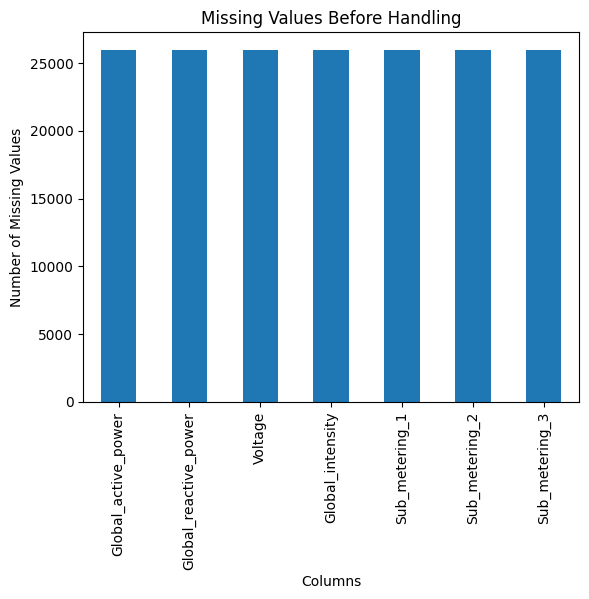

In [88]:


df.isnull().sum().plot(kind='bar')

plt.title("Missing Values Before Handling")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.show()

# Bar Plot Interpretation

The bar plot shows:

each column has around 25,979 missing values
all affected columns have nearly equal missing counts

This happened because missing rows affected multiple measurements at the same timestamps.

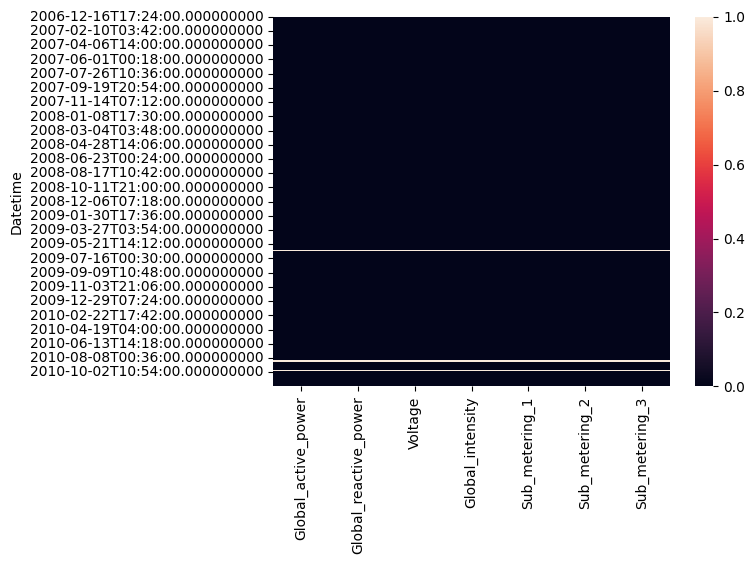

In [89]:


sns.heatmap(df.isnull())

plt.show()

## Heatmap Interpretation

In the heatmap:

dark/black area means data is present (False)
light horizontal lines means missing values (True / NaN)

So those white horizontal lines indicate:

* missing readings at specific timestamps

Since this is time-series data, the heatmap helps identify:

* where gaps occurred over time
* whether missing values are continuous or scattered




## Why color bar shows 0 and 1

Internally:

False = 0
True = 1

because:

df.isnull()

creates boolean values.

So:

0 → not missing
1 → missing

The heatmap converts them into colors.

In [90]:
df.interpolate(method= 'time',inplace=True)

### EXPLAINATION
method='time' was used because the dataset is a time-series dataset with a datetime index, and this method estimates missing values based on time intervals, preserving temporal continuity in energy consumption patterns.

In [91]:
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


#  Record Deduplication
* **Action:** Identifying and dropping over 142,582 duplicate rows (~7%) to prevent structural bias in model training.

In [92]:
df.duplicated().sum()

np.int64(142582)

In [93]:
df.drop_duplicates(inplace=True)

In [94]:
df.duplicated().sum()

np.int64(0)

In [95]:
df.shape

(1932677, 7)

# **Phase 3: Exploratory Data Analysis & Resampling**

# Temporal Resampling & Noise Reduction
* **Action:** Downsampling raw minute-by-minute metrics into Daily (`D`) and Monthly (`ME`) granularities to filter out high-frequency noise.

In [96]:
daily_data = df.resample('D').mean()
monthly_data = df.resample('ME').mean()

In [97]:
daily_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.353874,0.157058,240.089979,9.996525,1.412787,2.909659,9.259208
2006-12-18,1.535798,0.112559,241.215077,6.444073,0.741283,1.827755,9.775453
2006-12-19,1.158337,0.104967,241.996147,4.931711,0.583449,5.286509,4.309458
2006-12-20,1.558315,0.112863,242.283682,6.520731,0.000000,1.860155,9.844694


In [98]:
monthly_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-31,1.911651,0.132300,241.419290,8.074207,1.260128,2.234555,7.453300
2007-01-31,1.571197,0.135392,240.849772,6.653476,1.292622,1.815528,7.518279
2007-02-28,1.472168,0.120495,240.406336,6.217276,1.258111,1.708337,7.083789
2007-03-31,1.403988,0.123847,240.367357,5.936957,1.480365,2.550158,6.984312
2007-04-30,0.897646,0.130574,238.867436,3.862017,1.064760,0.968012,4.722409


In [99]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# Visualization / EDA

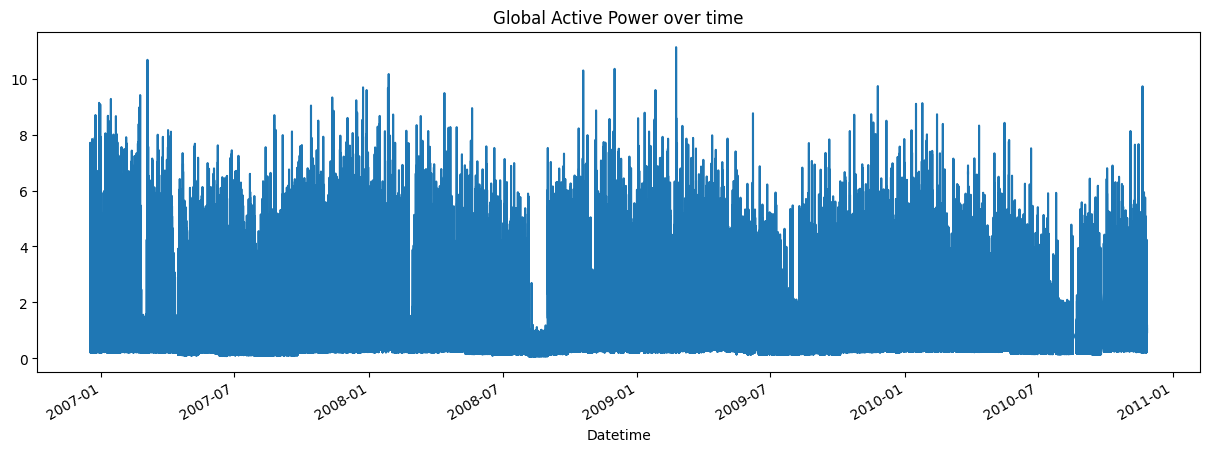

In [100]:
# 1. line plot


df['Global_active_power'].plot(figsize=(15,5))
plt.title("Global Active Power over time")
plt.show()

This is THE raw, high-frequency data.

* Seasonality: Seasonality is hard to see here because the minute-by-minute "noise" (spikes) hides the pattern.

* Stationarity: The fact that the average height of the "block" stays relatively the same over years suggests it might be stationary, but  need the rolling mean to confirm.

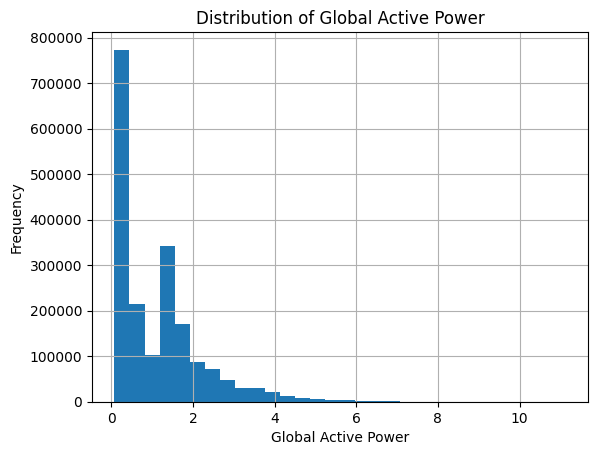

In [101]:
# 2. histogram

df['Global_active_power'].hist(bins=30)
plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power")
plt.ylabel("Frequency")
plt.show()

 * The data is actually Right-Skewed because the "tail" stretches out to the right (towards 10).

 * This indicates that for most of the time, energy use is very low (the tall peak near 0), and high energy usage events are rare but significant.

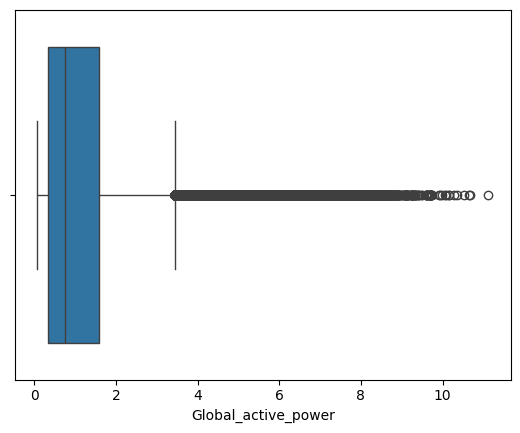

In [102]:
# 3. BOXPLOT

sns.boxplot(x=df['Global_active_power'])
plt.show()

*  The long line of dots to the right are outliers.


* These are not necessarily "bad" data; they represent heavy appliance use (like an AC or heater turning on).

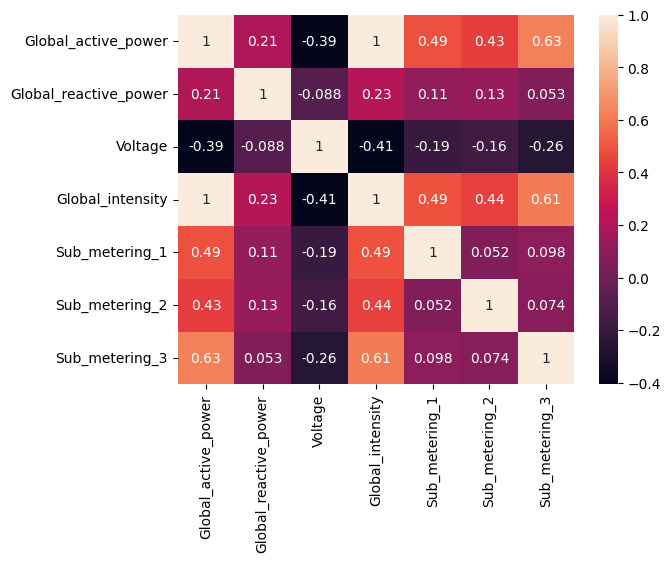

In [103]:
#4. heatmap

import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()

* Global_active_power has a nearly perfect correlation (1.0) with Global_intensity.

* Sub-metering: Sub-metering 3 has the highest correlation (0.63) with the total power, meaning that specific area of the house (AC) is a major driver of total energy use.

* Voltage: There is a weak negative correlation (-0.4) with power. Generally, as consumption (load) increases, voltage can experience a slight drop.

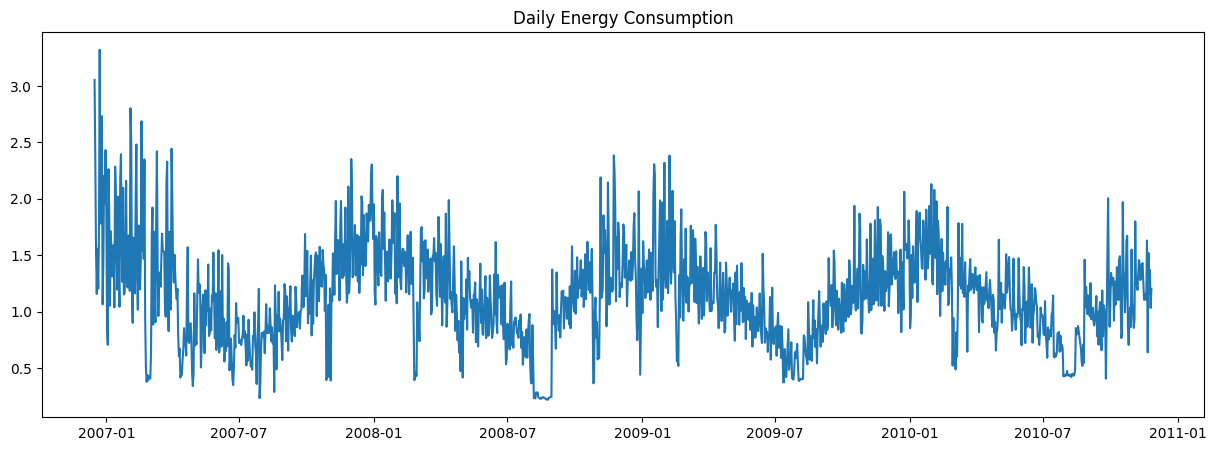

In [104]:
# daily consumption plot
plt.figure(figsize = (15,5))
plt.plot(daily_data['Global_active_power'])
plt.title("Daily Energy Consumption")
plt.show()


 * seasonality found: the "wavy" shape is the seasonality.

 * high peaks in january and dips in july

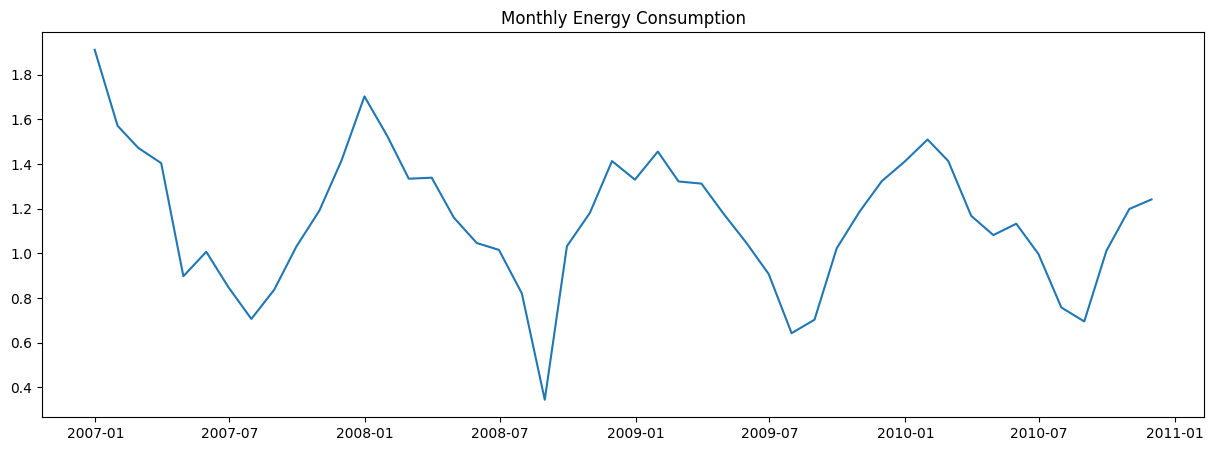

In [105]:
# monthly consumption plot
plt.figure(figsize = (15,5))
plt.plot(monthly_data['Global_active_power'])
plt.title("Monthly Energy Consumption")
plt.show()


It confirms that energy use peaks every winter and drops every summer, which is the definition of Seasonal Trend.

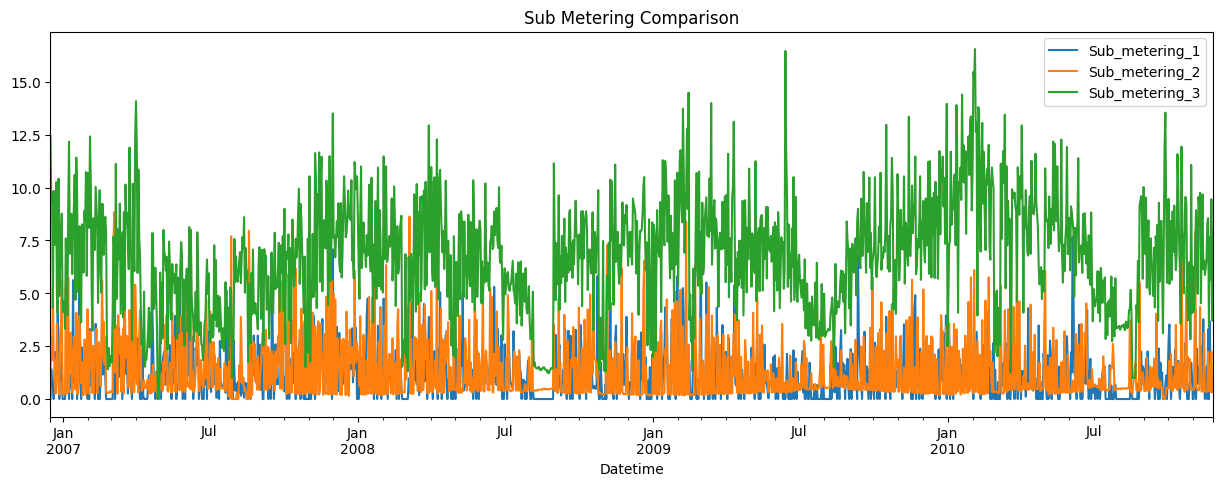

In [106]:
# sub metrics comparision
daily_data[['Sub_metering_1',
            'Sub_metering_2',
            'Sub_metering_3']].plot(figsize=(15,5))

plt.title("Sub Metering Comparison")
plt.show()

# daily_data[['Sub_metering_1',
#             'Sub_metering_2',
#             'Sub_metering_3']].plot(kind='bar', figsize=(15,5))
# plt.title("Sub Metering Comparison")
# plt.show()

sub_metrics 3 (AC/Heater)	 is Primary driver of high-load energy consumption.

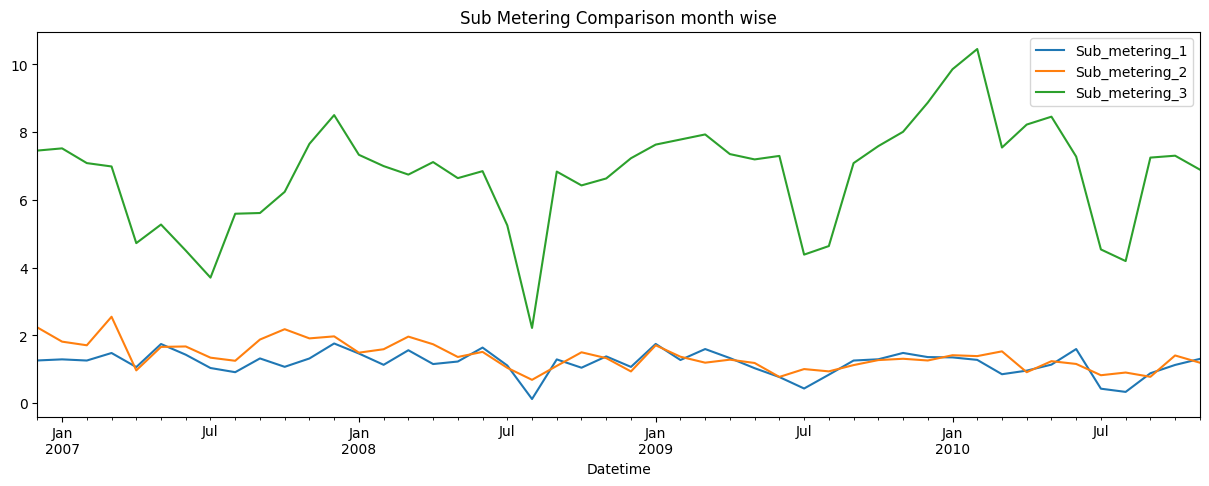

In [107]:
monthly_data[['Sub_metering_1',
            'Sub_metering_2',
            'Sub_metering_3']].plot(figsize=(15,5))

plt.title("Sub Metering Comparison month wise")
plt.show()

* The July 2008 Drop:  we can see a massive "V" shape where usage almost hits zero in July 2008.

* The Jan 2010 Peak: The high usage in January 2010 aligns with winter heating needs.

* monthly plot  confirms a strong seasonal cycle. The energy usage it expands in the winter (January) and contracts in the summer (July).

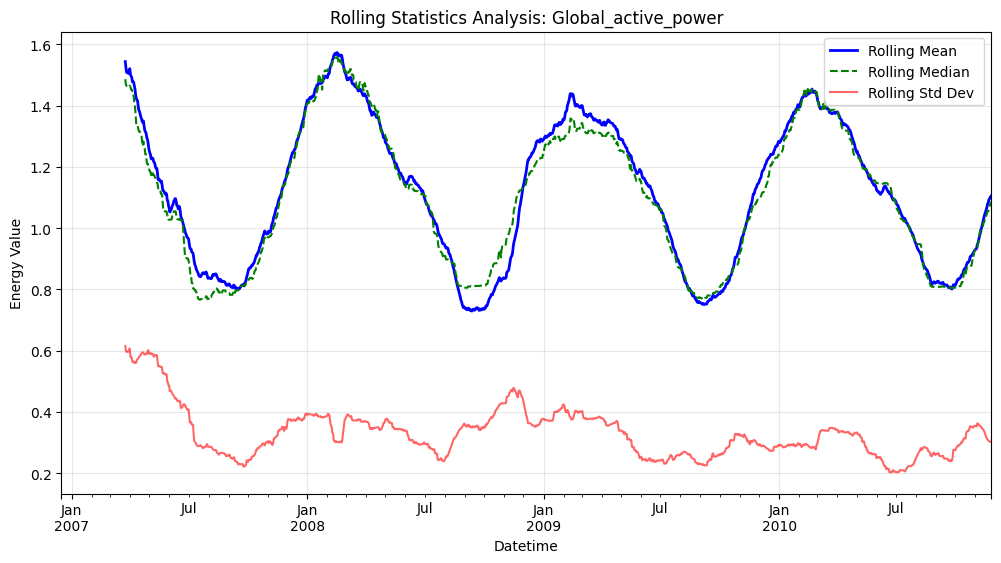

In [108]:


# 1. Focus on one specific column for the comparison
target_col = 'Global_active_power'
roll = daily_data[target_col].rolling(window=100)

# 2. Plotting
plt.figure(figsize=(12,6))

# The average value (Trend)
roll.mean().plot(label='Rolling Mean ', color='blue', linewidth=2)

# The typical value (Robust to spikes)
roll.median().plot(label='Rolling Median ', color='green', linestyle='--')

# The volatility (Risk/Shakiness)
roll.std().plot(label='Rolling Std Dev ', color='red', alpha=0.6)

plt.title(f"Rolling Statistics Analysis: {target_col}")
plt.ylabel("Energy Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



Non-Stationarity:  the lines are not flat. For a dataset to be "Stationary," the mean and variance should be constant over time.

The Evidence: Because the Rolling Mean (Blue) and Rolling Std Dev (Red) are waving up and down like a roller coaster, the data is Non-Stationary.

we have to "difference" the data   to flatten those lines out.then oly the model works

 # **Project Insight Summary: Household Energy Analysis**

## 1. Data Integrity & Cleaning



* **Action:** Removed 142,582 duplicate records (approx. 7% of raw data) to prevent bias in averages and model overfitting.

* **Action:** Handled missing values via linear interpolation to maintain the continuous flow required for time-series forecasting.

## 2. Consumption Distribution

* **Histogram Analysis:** The data is right-skewed, meaning the household spends most of its time at low power, with high-energy "spikes" being significant but less frequent.

* **Outlier Detection:** Box plots confirm numerous high-wattage outliers, representing heavy appliance usage rather than data errors.

## 3. Sub-metering Dominance

* **Primary Driver:** Sub_metering_3 (Water-heater/AC) is the dominant consumer. It shows a strong positive correlation (0.63) with total Global Active Power.

* **Behavioral Anomalies:** Identified a significant drop in July 2008 (likely a vacation/absence) and a massive sustained role in July 2009, which explains the summer energy peak for that year.

## 4. Seasonal Trends & Time Analysis

* **Seasonality:** Clear cyclical patterns are visible in monthly plots, with consumption peaking in January and dipping in July.

* **Yearly Comparison:** While 2007–2010 follow a consistent seasonal "wave," comparing them side-by-side reveals shifts in peak intensity, such as the increased demand seen in early 2010.

## 5. Modeling Readiness

* **Non-Stationarity:** Rolling statistics (Mean and Std Dev) are not flat; they move with the seasons.

*  **Conclusion:** The data is non-stationary, meaning it will require techniques like differencing or seasonal decomposition before applying forecasting models like ARIMA or LSTMs.

# Statistical Baseline Implementation
* **Action:** Importing statsmodels tools to build and fit the SARIMA framework.

# ADF TEST

WE suspect non-stationarity from rolling statistics.

Now statistically confirm it SO we use Augmented Dickey-Fuller, it test checks whether a time series is stationary.

(if p-value <0.05 = Stationarity or p-value >0.05 = non stationarity)


In [109]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    daily_data['Global_active_power'].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.5690138258046065
p-value: 0.006381809016064745


In [110]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    monthly_data['Global_active_power'].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.735812573682122
p-value: 6.442473546337367e-07


* Both daily and monthly energy consumption series were found to be statistically stationary according to the Augmented Dickey-Fuller (ADF) test.

* Although visual seasonal variations and cyclical consumption trends were observed, the statistical properties of the series remained stable enough for time-series forecasting models such as SARIMA and Prophet.

# ACF & PACF PLOTS


* **Action:** Reviewing Autocorrelation and Partial Autocorrelation functions to extract the structural 7-day seasonal cycle.

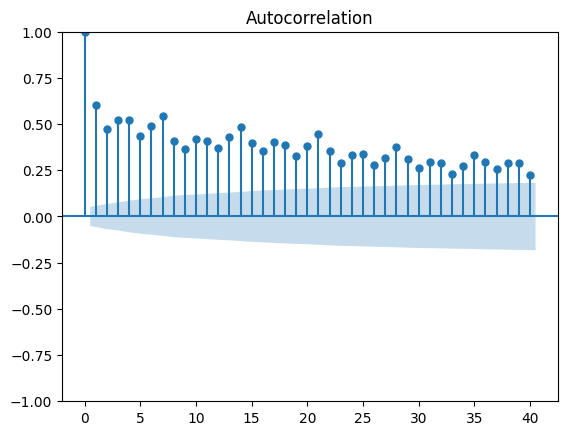

In [111]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(
    daily_data['Global_active_power'].dropna(),
    lags=40
)

plt.show()

* The bars show a "tailing off" or gradual decay pattern rather than a sudden drop into the blue boundary.

* This indicates that the moving average components ($q$ and $Q$) should be 0.

* You can see recurring "humps" at lags 7, 14, and 21, which confirms a weekly (7-day) seasonal cycle in your energy data.

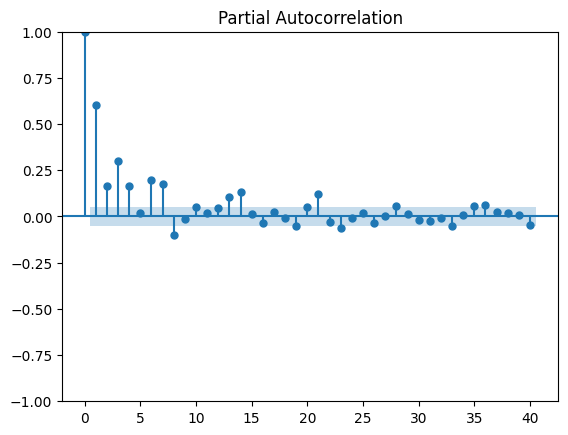

In [112]:
plot_pacf(
    daily_data['Global_active_power'].dropna(),
    lags=40
)

plt.show()

* There is a sharp cut-off after the first few lags.

* Lag 1 is the most dominant spike outside the blue boundary, which identifies the primary relationship between today and yesterday.

* There is also a significant spike at Lag 7, which helps identify the seasonal relationship.

# INTERPRETATIONS OF ACF &PACF PLOTS

**Non-seasonal Part**

* *p = 1*

Uses the previous day’s energy consumption to predict the current day.

Good interpretation:  yesterday influences today.

---





* *d = 0*

No regular differencing required because ADF indicated stationarity.




---


* *q = 0*

No moving-average error smoothing needed because ACF likely did not show strong MA behavior.

Also reasonable.



---




**Seasonal Part**



*  *P = 1*

Uses the previous seasonal cycle.

Since:

s = 7

this means:

the model considers the value from the same day last week.

Very appropriate for daily energy usage data.


---


* *D = 0*

No seasonal differencing required.

Correct because:

ADF already indicated stationarity
seasonal cycles appear stable



---



* *Q = 0*

No seasonal moving-average correction required.

Again acceptable if seasonal ACF spikes were weak.




# SARIMA MODEL

SARIMA stands for Seasonal Autoregressive Integrated Moving Average.

In short, it is a time series forecasting model used when data has:

* Trend (up/down over time)
Seasonality (repeating patterns like monthly or yearly cycles)

* It extends ARIMA by adding a seasonal component, so it can better predict things like:

*  * electricity usage
* * sales
* * temperature
* * website traffic

 SARIMA = ARIMA + seasonality handling




In [113]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [114]:
train = daily_data[:'2009']
test = daily_data['2010':]

In [115]:
print(f"Last date in train: {train.index.max()}")
print(f"First date in test: {test.index.min()}")
print(f"Total rows: {len(train) + len(test)} (Original: {len(daily_data)})")

Last date in train: 2009-12-31 00:00:00
First date in test: 2010-01-01 00:00:00
Total rows: 1442 (Original: 1442)


In [116]:
model = SARIMAX(
    train['Global_active_power'],
    order=(1,0,0),
    seasonal_order=(1,0,0,7)
)

model_fit = model.fit()

In [117]:
print(model_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:               Global_active_power   No. Observations:                 1112
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 7)   Log Likelihood                -484.365
Date:                           Fri, 15 May 2026   AIC                            974.731
Time:                                   11:08:50   BIC                            989.773
Sample:                               12-16-2006   HQIC                           980.418
                                    - 12-31-2009                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9028      0.011     82.790      0.000       0.881       0.924
ar.S.L7        0.3313      0.025     13.285

# INSIGHTS OF MODEL SARIMAX
* ar.L1 = 0.9028

Very strong positive relationship with previous day’s consumption.

Interpretation:

Today’s energy usage is highly influenced by yesterday’s usage.

Since:

0.90 ≈ close to 1

the dependency is strong.


---


* ar.S.L7 = 0.3313

Weekly seasonal effect exists.

Interpretation:

Consumption patterns from the same day in the previous week also influence current energy usage.


---


* p-values

All coefficients show:

P>|z| = 0.000

Meaning:

statistically significant
model parameters are meaningful

This is good.


---


* AIC = 974.731

AIC helps compare models.

Lower AIC = generally better.

we can later compare with:

other SARIMA combinations
Prophet model


---


**Diagnostic Section**

* Ljung-Box
Prob(Q) = 0.00

Indicates:

some autocorrelation may still remain in residuals

This means:

the model may not capture all temporal patterns perfectly.

This is common.


---


* Jarque-Bera
Prob(JB) = 0.00

Residuals are not perfectly normally distributed.

Also common in real-world energy data.



# Overall Interpretation for Project



The SARIMA(1,0,0)(1,0,0,7) model successfully captured both short-term and weekly seasonal dependencies in household energy consumption. The autoregressive coefficients were statistically significant, indicating that previous daily and weekly consumption patterns strongly influence current energy usage.

In [118]:
forecast = model_fit.forecast(steps=len(test))

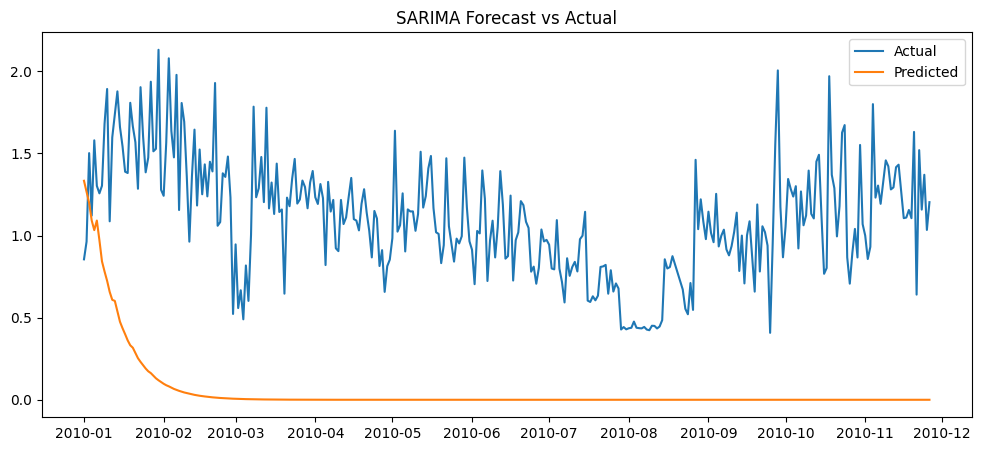

In [119]:
plt.figure(figsize=(12,5))

plt.plot(test.index,
         test['Global_active_power'],
         label='Actual')

plt.plot(test.index,
         forecast,
         label='Predicted')

plt.legend()

plt.title("SARIMA Forecast vs Actual")

plt.show()

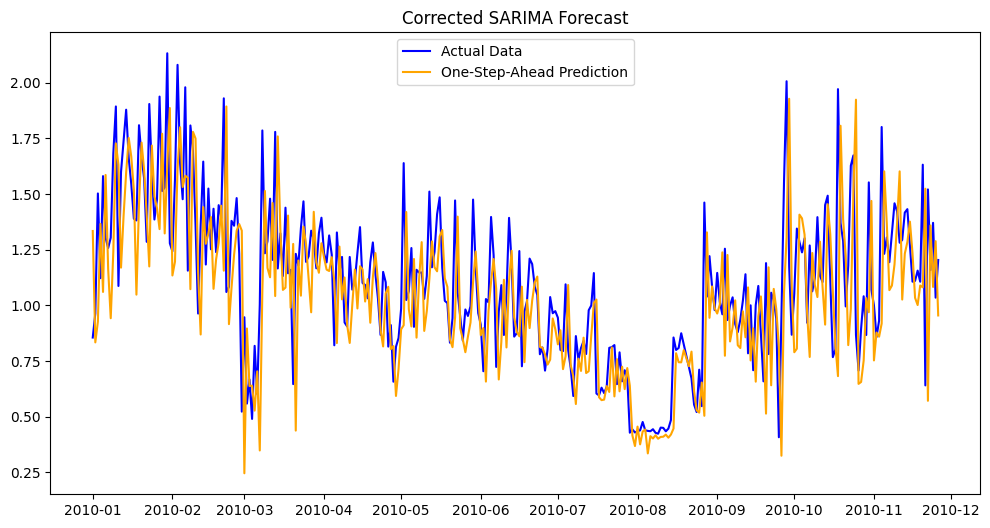

In [120]:
# 1. 'extend' tells the model: "Here is the real data for 2010.
# Use it to update your memory, but keep the same math (p,d,q) we found."
results_extended = model_fit.extend(test['Global_active_power'])

# 2. Now, when we predict, the model can look at the ACTUAL value of
# the previous day to make its next guess.
predictions = results_extended.get_prediction(start=test.index[0], end=test.index[-1])
final_pred = predictions.predicted_mean

# 3. Plotting the results

plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Global_active_power'], label='Actual Data', color='blue')
plt.plot(test.index, final_pred, label='One-Step-Ahead Prediction', color='orange')
plt.legend()
plt.title('Corrected SARIMA Forecast')
plt.show()

In [121]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


mae = mean_absolute_error(
    test['Global_active_power'],
    final_pred
)

print("MAE:", mae)

MAE: 0.22542287687950058


In [122]:
rmse = np.sqrt(
    mean_squared_error(
        test['Global_active_power'],
        final_pred
    )
)

print("RMSE:", rmse)

RMSE: 0.3111555935822691


In [123]:
print(daily_data['Global_active_power'].describe())

count    1442.000000
mean        1.135736
std         0.428429
min         0.220947
25%         0.851973
50%         1.115320
75%         1.382723
max         3.320554
Name: Global_active_power, dtype: float64


The Industry Problem with SARIMA for 2027:

Mean Reversion: Because SARIMA doesn't "know" the year is 2027, it will eventually lose the seasonal signal and "flatten out" toward the average (mean) of your training data.

Error Accumulation: If one prediction is slightly off, the next one (which depends on the first) will be further off. By the time you reach 2027, the "confidence intervals" will be so wide they become useless.

# FINAL INTERPRETATION
"The SARIMA model achieved a Mean Absolute Error (MAE) of 0.225 kW and a Root Mean Squared Error (RMSE) of 0.311 kW. Given that the baseline dataset has a mean daily consumption of 1.136 kW and a natural standard deviation of 0.428 kW, the model's average error represents a modest ~19.8% deviation from the mean. Furthermore, because the RMSE remains well below the data's standard deviation, the model demonstrates strong predictive power rather than mere mean reversion."